# Que hace `run_libribrain_evals.sh`

Este notebook documenta, con codigo inspeccionable y plots, que ocurre al ejecutar:

```bash
bash run_libribrain_evals.sh
```

No lanza Docker ni entrena modelos. Lee el script, `docker-compose.yml`, las configuraciones Hydra de LibriBrain y los metadatos/eventos locales para explicar la orquestacion, las frecuencias de preprocesado y las frecuencias de palabras que condicionan las metricas `top-k`.

## Resumen ejecutivo

Por defecto el script hace tres cosas:

1. Prepara variables de entorno, directorios de cache/logs y valida que existan checkpoint, dataset y metadatos de sensores de LibriBrain.
2. Construye las imagenes Docker de los servicios seleccionados con `docker compose build`.
3. Arranca el monitor y ejecuta secuencialmente dos evaluaciones: primero `eval_libribrain` y, solo si termina con codigo 0, `eval_libribrain_linear_probe`.

Las dos evaluaciones usan el mismo dataset y split, pero difieren en la cabeza entrenada: la primera entrena una MLP sobre features CrissCross; la segunda congela el backbone y entrena una capa lineal.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import csv
import hashlib
import os
import re
import textwrap

import yaml
import matplotlib.pyplot as plt

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = print

ROOT = Path.cwd()
if not (ROOT / 'run_libribrain_evals.sh').exists():
    ROOT = ROOT.parent

SCRIPT = ROOT / 'run_libribrain_evals.sh'
COMPOSE = ROOT / 'docker-compose.yml'
EVAL_CFG = ROOT / 'configs/eval_criss_cross_word_classification_libribrain.yaml'
LINEAR_CFG = ROOT / 'configs/eval_criss_cross_word_classification_linear_probe_libribrain.yaml'

script_text = SCRIPT.read_text()
compose_cfg = yaml.safe_load(COMPOSE.read_text())
eval_cfg = yaml.safe_load(EVAL_CFG.read_text())
linear_cfg = yaml.safe_load(LINEAR_CFG.read_text())

plt.style.use('seaborn-v0_8-whitegrid')

def md_table(headers, rows):
    lines = ['|' + '|'.join(headers) + '|', '|' + '|'.join(['---'] * len(headers)) + '|']
    for row in rows:
        lines.append('|' + '|'.join(str(x) for x in row) + '|')
    return '\n'.join(lines)

print(f'Repo: {ROOT}')
print(f'Script encontrado: {SCRIPT.relative_to(ROOT)}')

Repo: /home/odra/GitHub/ScraBrain
Script encontrado: run_libribrain_evals.sh


In [2]:
env_defaults = [
    ('EVAL_GPU', '0', 'GPU para `eval_libribrain`'),
    ('LINEAR_PROBE_GPU', '1', 'GPU para `eval_libribrain_linear_probe`'),
    ('MONITOR_PORT', '8080', 'Puerto host para el monitor'),
    ('DATASETS_DIR', './datasets', 'Montaje host de datasets'),
    ('LIBRIBRAIN_ROOT', './datasets/libribrain', 'Ruta LibriBrain dentro del repo/contenedor'),
    ('CHECKPOINTS_DIR', './checkpoints', 'Montaje host de checkpoints'),
    ('CRISS_CROSS_CHECKPOINT', './checkpoints/baseline/meg-xl-med.ckpt', 'Checkpoint que se inyecta como override Hydra'),
    ('WANDB_MODE', 'offline', 'WandB por defecto sin red'),
]

options = [
    ('--no-build', 'salta `docker compose build`'),
    ('--no-monitor', 'no arranca el monitor'),
    ('--monitor-only', 'solo arranca el monitor y no valida inputs de evaluacion'),
    ('--eval-only', 'solo arranca `eval_libribrain`'),
    ('--linear-probe-only', 'solo arranca `eval_libribrain_linear_probe`'),
    ('--logs', 'sigue logs durante la ejecucion'),
]

display(Markdown('### Variables por defecto\n' + md_table(['Variable', 'Default', 'Uso'], env_defaults)))
display(Markdown('### Flags del script\n' + md_table(['Flag', 'Efecto'], options)))

### Variables por defecto
|Variable|Default|Uso|
|---|---|---|
|EVAL_GPU|0|GPU para `eval_libribrain`|
|LINEAR_PROBE_GPU|1|GPU para `eval_libribrain_linear_probe`|
|MONITOR_PORT|8080|Puerto host para el monitor|
|DATASETS_DIR|./datasets|Montaje host de datasets|
|LIBRIBRAIN_ROOT|./datasets/libribrain|Ruta LibriBrain dentro del repo/contenedor|
|CHECKPOINTS_DIR|./checkpoints|Montaje host de checkpoints|
|CRISS_CROSS_CHECKPOINT|./checkpoints/baseline/meg-xl-med.ckpt|Checkpoint que se inyecta como override Hydra|
|WANDB_MODE|offline|WandB por defecto sin red|

### Flags del script
|Flag|Efecto|
|---|---|
|--no-build|salta `docker compose build`|
|--no-monitor|no arranca el monitor|
|--monitor-only|solo arranca el monitor y no valida inputs de evaluacion|
|--eval-only|solo arranca `eval_libribrain`|
|--linear-probe-only|solo arranca `eval_libribrain_linear_probe`|
|--logs|sigue logs durante la ejecucion|

## Orquestacion del shell

El comportamiento importante esta en la rama en la que se seleccionan las dos evaluaciones. En esa rama el script no las deja corriendo en paralelo: arranca un contenedor, espera su salida con `docker wait`, comprueba el codigo de salida, y solo entonces pasa al siguiente servicio.

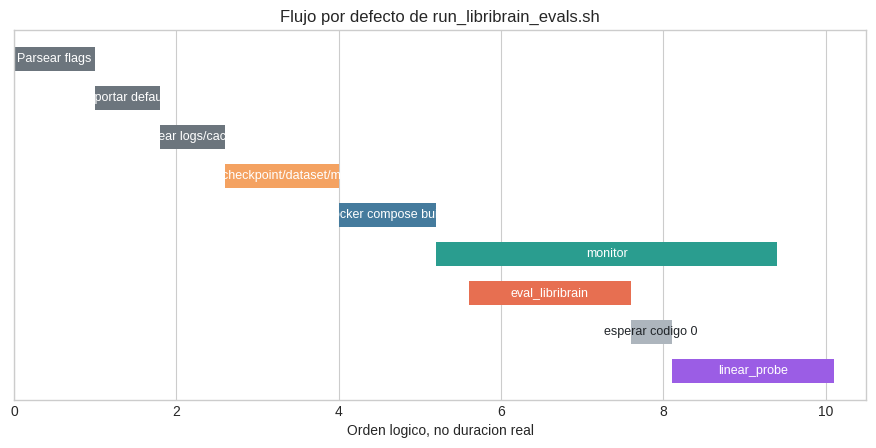

In [3]:
steps = [
    ('Parsear flags', 0, 1.0, '#6c757d'),
    ('Exportar defaults', 1.0, 0.8, '#6c757d'),
    ('Crear logs/cache', 1.8, 0.8, '#6c757d'),
    ('Validar checkpoint/dataset/metadata', 2.6, 1.4, '#f4a261'),
    ('docker compose build', 4.0, 1.2, '#457b9d'),
    ('monitor', 5.2, 4.2, '#2a9d8f'),
    ('eval_libribrain', 5.6, 2.0, '#e76f51'),
    ('esperar codigo 0', 7.6, 0.5, '#adb5bd'),
    ('linear_probe', 8.1, 2.0, '#9b5de5'),
]

fig, ax = plt.subplots(figsize=(11, 4.8))
for i, (label, start, duration, color) in enumerate(steps):
    ax.barh(i, duration, left=start, color=color, height=0.62)
    ax.text(start + duration / 2, i, label, ha='center', va='center', color='white' if color != '#adb5bd' else '#212529', fontsize=9)
ax.set_yticks([])
ax.set_xlabel('Orden logico, no duracion real')
ax.set_title('Flujo por defecto de run_libribrain_evals.sh')
ax.set_xlim(0, 10.5)
ax.invert_yaxis()
plt.show()

In [4]:
services = compose_cfg['services']
rows = []
for service_name in ['monitor', 'eval_libribrain', 'eval_libribrain_linear_probe']:
    service = services[service_name]
    command = ' '.join(str(service.get('command', '')).split())
    gpu = service.get('environment', {}).get('NVIDIA_VISIBLE_DEVICES', '-')
    rows.append((service_name, service.get('container_name', '-'), gpu, '`' + command + '`'))

display(Markdown(md_table(['Servicio', 'Contenedor', 'GPU visible', 'Comando'], rows)))

|Servicio|Contenedor|GPU visible|Comando|
|---|---|---|---|
|monitor|scrabrain_monitor|-|`bash -lc 'uv run --no-sync python monitor_server.py --host 0.0.0.0 --port 8080 --base-dir /workspace'`|
|eval_libribrain|scrabrain_eval_libribrain|${EVAL_GPU:-0}|`bash -lc 'uv run --no-sync python -m brainstorm.evaluate_criss_cross_word_classification --config-name=eval_criss_cross_word_classification_libribrain model.criss_cross_checkpoint="$${CRISS_CROSS_CHECKPOINT}" data.root="$${LIBRIBRAIN_ROOT}" hydra.run.dir="./logs/hydra/eval_libribrain/$$(date +%Y%m%d_%H%M%S)"'`|
|eval_libribrain_linear_probe|scrabrain_eval_libribrain_linear_probe|${LINEAR_PROBE_GPU:-1}|`bash -lc 'uv run --no-sync python -m brainstorm.evaluate_criss_cross_word_classification_linear_probe --config-name=eval_criss_cross_word_classification_linear_probe_libribrain model.criss_cross_checkpoint="$${CRISS_CROSS_CHECKPOINT}" data.root="$${LIBRIBRAIN_ROOT}" hydra.run.dir="./logs/hydra/eval_libribrain_linear_probe/$$(date +%Y%m%d_%H%M%S)"'`|

## Configuracion efectiva de LibriBrain

Los servicios de Compose pasan dos overrides Hydra a las configs: `model.criss_cross_checkpoint=$CRISS_CROSS_CHECKPOINT` y `data.root=$LIBRIBRAIN_ROOT`. Por tanto, el checkpoint por defecto de la YAML queda reemplazado por el valor exportado por el shell.

In [5]:
data_cfg = eval_cfg['data']
train_cfg = eval_cfg['training']
summary_rows = [
    ('dataset_type', data_cfg['dataset_type']),
    ('subjects', ', '.join(data_cfg['subjects'])),
    ('sessions usadas por hash', ', '.join(data_cfg['all_sessions'])),
    ('split_ratios', data_cfg['split_ratios']),
    ('train_pct despues del hash', data_cfg['train_pct']),
    ('segment_length', f"{data_cfg['segment_length']} s"),
    ('subsegment_duration', f"{data_cfg['subsegment_duration']} s"),
    ('words_per_segment', data_cfg['words_per_segment']),
    ('window_onset_offset', f"{data_cfg['window_onset_offset']} s"),
    ('l_freq/h_freq', f"{data_cfg['l_freq']} - {data_cfg['h_freq']} Hz"),
    ('target_sfreq', f"{data_cfg['target_sfreq']} Hz"),
    ('batch_size / epochs', f"{train_cfg['batch_size']} / {train_cfg['num_epochs']}"),
    ('retrieval_set_sizes', eval_cfg['evaluation']['retrieval_set_sizes']),
    ('top-k', eval_cfg['evaluation']['k']),
]

display(Markdown(md_table(['Parametro', 'Valor'], summary_rows)))

expected_segment = data_cfg['subsegment_duration'] * data_cfg['words_per_segment']
print(f"Comprobacion: {data_cfg['words_per_segment']} palabras x {data_cfg['subsegment_duration']} s = {expected_segment} s")
print(f"segment_length configurado = {data_cfg['segment_length']} s")

|Parametro|Valor|
|---|---|
|dataset_type|libribrain|
|subjects|sub-0|
|sessions usadas por hash|ses-1, ses-2, ses-3, ses-4, ses-5, ses-6, ses-7, ses-8, ses-9, ses-10|
|split_ratios|[0.8, 0.1, 0.1]|
|train_pct despues del hash|0.25|
|segment_length|150.0 s|
|subsegment_duration|3.0 s|
|words_per_segment|50|
|window_onset_offset|-0.5 s|
|l_freq/h_freq|0.1 - 40.0 Hz|
|target_sfreq|50.0 Hz|
|batch_size / epochs|1 / 50|
|retrieval_set_sizes|[50, 250]|
|top-k|10|

Comprobacion: 50 palabras x 3.0 s = 150.0 s
segment_length configurado = 150.0 s


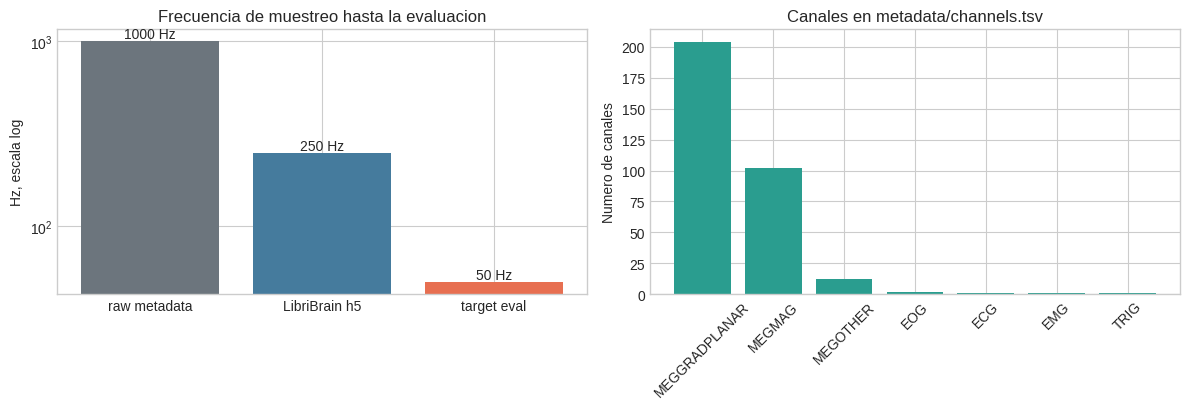

Filtro usado por la evaluacion: band-pass 0.1 - 40.0 Hz; remuestreo a 50.0 Hz.
Frecuencias declaradas en channels.tsv: {1000.0: 323}


In [6]:
freq_rows = []
channels_path = ROOT / 'datasets/libribrain/metadata/channels.tsv'
if channels_path.exists():
    with channels_path.open() as f:
        for row in csv.DictReader(f, delimiter='\t'):
            freq_rows.append(row)

type_counts = Counter(row['type'] for row in freq_rows)
sampling_counts = Counter(float(row['sampling_frequency']) for row in freq_rows if row.get('sampling_frequency'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

stages = ['raw metadata', 'LibriBrain h5', 'target eval']
sfreqs = [1000.0, 250.0, float(data_cfg['target_sfreq'])]
axes[0].bar(stages, sfreqs, color=['#6c757d', '#457b9d', '#e76f51'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Hz, escala log')
axes[0].set_title('Frecuencia de muestreo hasta la evaluacion')
for x, y in zip(stages, sfreqs):
    axes[0].text(x, y, f'{y:g} Hz', ha='center', va='bottom')

if type_counts:
    labels, values = zip(*type_counts.most_common())
    axes[1].bar(labels, values, color='#2a9d8f')
    axes[1].set_title('Canales en metadata/channels.tsv')
    axes[1].set_ylabel('Numero de canales')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No se encontro channels.tsv', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Filtro usado por la evaluacion: band-pass {data_cfg['l_freq']} - {data_cfg['h_freq']} Hz; remuestreo a {data_cfg['target_sfreq']} Hz.")
if sampling_counts:
    print('Frecuencias declaradas en channels.tsv:', dict(sampling_counts))

## Frecuencias de palabras y splits

La evaluacion construye vocabulario con todas las palabras presentes en los segmentos, ordenadas por frecuencia. Las metricas `top-10@50` y `top-10@250` solo evaluan muestras cuya palabra verdadera esta entre las 50 o 250 palabras mas frecuentes, respectivamente.

La celda siguiente reproduce la parte ligera del dataset: lee `events.tsv`, filtra `kind == word`, descarta `silence`, agrupa palabras consecutivas en bloques de `words_per_segment` y aplica el mismo hash SHA256 por frase para asignar `train/val/test`. Si `h5py` esta disponible, tambien usa la duracion del HDF5 para descartar ventanas fuera de rango como hace `LibriBrainWordAlignedDataset`.

In [7]:
def parse_event_name(path):
    match = re.search(r'(sub-[^_]+)_(ses-[^_]+)_task-([^_]+)_(run-[^_]+)_events.tsv$', path.name)
    if not match:
        return None
    return dict(subject=match.group(1), session=match.group(2), task=match.group(3), run=match.group(4))

def sentence_split(words, ratios, seed):
    sentence = ' '.join(words)
    value = int(hashlib.sha256(f'{seed}:{sentence}'.encode('utf-8')).hexdigest(), 16) / (2**256)
    cumulative = 0.0
    for name, ratio in zip(['train', 'val', 'test'], ratios):
        cumulative += ratio
        if value < cumulative:
            return name
    return 'test'

def matching_h5(event_path):
    serialised = event_path.parent.parent / 'serialised'
    prefix = event_path.name.replace('_events.tsv', '')
    matches = sorted(serialised.glob(prefix + '*_meg.h5'))
    return matches[0] if matches else None

def h5_duration_seconds(h5_path):
    if h5_path is None:
        return None
    try:
        import h5py
        with h5py.File(h5_path, 'r') as h5:
            n_samples = h5['data'].shape[1]
            sfreq = float(h5.attrs.get('sample_frequency', 250.0))
        return n_samples / sfreq
    except Exception:
        return None

def load_word_events(event_path):
    rows = []
    with event_path.open() as f:
        for row in csv.DictReader(f, delimiter='\t'):
            if row.get('kind') != 'word':
                continue
            word = str(row.get('segment', '')).strip().lower()
            if not word or word == 'silence':
                continue
            try:
                onset = float(row['timemeg'])
            except Exception:
                continue
            rows.append((onset, word))
    return sorted(rows)

def build_groups(events, duration, words_per_segment, subsegment_duration, onset_offset):
    groups = []
    current = []
    for onset, word in events:
        if duration is not None:
            window_start = onset + onset_offset
            window_end = window_start + subsegment_duration
            if window_start < 0 or window_end > duration:
                current = []
                continue
        current.append(word)
        if len(current) == words_per_segment:
            groups.append(tuple(current))
            current = []
    return groups

root = ROOT / data_cfg['root'].replace('./', '')
all_events = sorted(root.glob('*/derivatives/events/*_events.tsv'))
subjects = set(data_cfg['subjects']) if data_cfg.get('subjects') else None
sessions = set(data_cfg['all_sessions']) if data_cfg.get('all_sessions') else None
tasks = set(data_cfg['tasks']) if data_cfg.get('tasks') else None

selected_events = []
for path in all_events:
    meta = parse_event_name(path)
    if meta is None:
        continue
    if subjects and meta['subject'] not in subjects:
        continue
    if sessions and meta['session'] not in sessions:
        continue
    if tasks and meta['task'] not in tasks:
        continue
    selected_events.append((path, meta))

word_counter = Counter()
raw_word_counter = Counter()
task_segments = Counter()
session_segments = Counter()
split_segments = Counter()
sentences = Counter()
used_h5_duration = 0

for event_path, meta in selected_events:
    events = load_word_events(event_path)
    raw_word_counter.update(word for _, word in events)
    duration = h5_duration_seconds(matching_h5(event_path))
    if duration is not None:
        used_h5_duration += 1
    groups = build_groups(
        events,
        duration,
        data_cfg['words_per_segment'],
        data_cfg['subsegment_duration'],
        data_cfg['window_onset_offset'],
    )
    for group in groups:
        word_counter.update(group)
        task_segments[meta['task']] += 1
        session_segments[meta['session']] += 1
        split_segments[sentence_split(group, data_cfg['split_ratios'], eval_cfg['seed'])] += 1
        sentences[' '.join(group)] += 1

train_after_subsample = int(split_segments['train'] * data_cfg['train_pct'])

print(f'Eventos seleccionados: {len(selected_events)} de {len(all_events)}')
print(f'Eventos con duracion HDF5 disponible: {used_h5_duration}')
print(f'Segmentos de {data_cfg["words_per_segment"]} palabras: {sum(task_segments.values())}')
print(f'Vocabulario en segmentos: {len(word_counter)} palabras unicas')
print(f'Frases unicas: {len(sentences)}; frases repetidas: {sum(1 for c in sentences.values() if c > 1)}')
print(f'Split por hash antes de submuestrear train: {dict(split_segments)}')
print(f'Train final aproximado tras train_pct={data_cfg["train_pct"]}: {train_after_subsample} segmentos')

Eventos seleccionados: 69 de 90
Eventos con duracion HDF5 disponible: 69
Segmentos de 50 palabras: 7417
Vocabulario en segmentos: 15406 palabras unicas
Frases unicas: 7417; frases repetidas: 0
Split por hash antes de submuestrear train: {'train': 5939, 'val': 753, 'test': 725}
Train final aproximado tras train_pct=0.25: 1484 segmentos


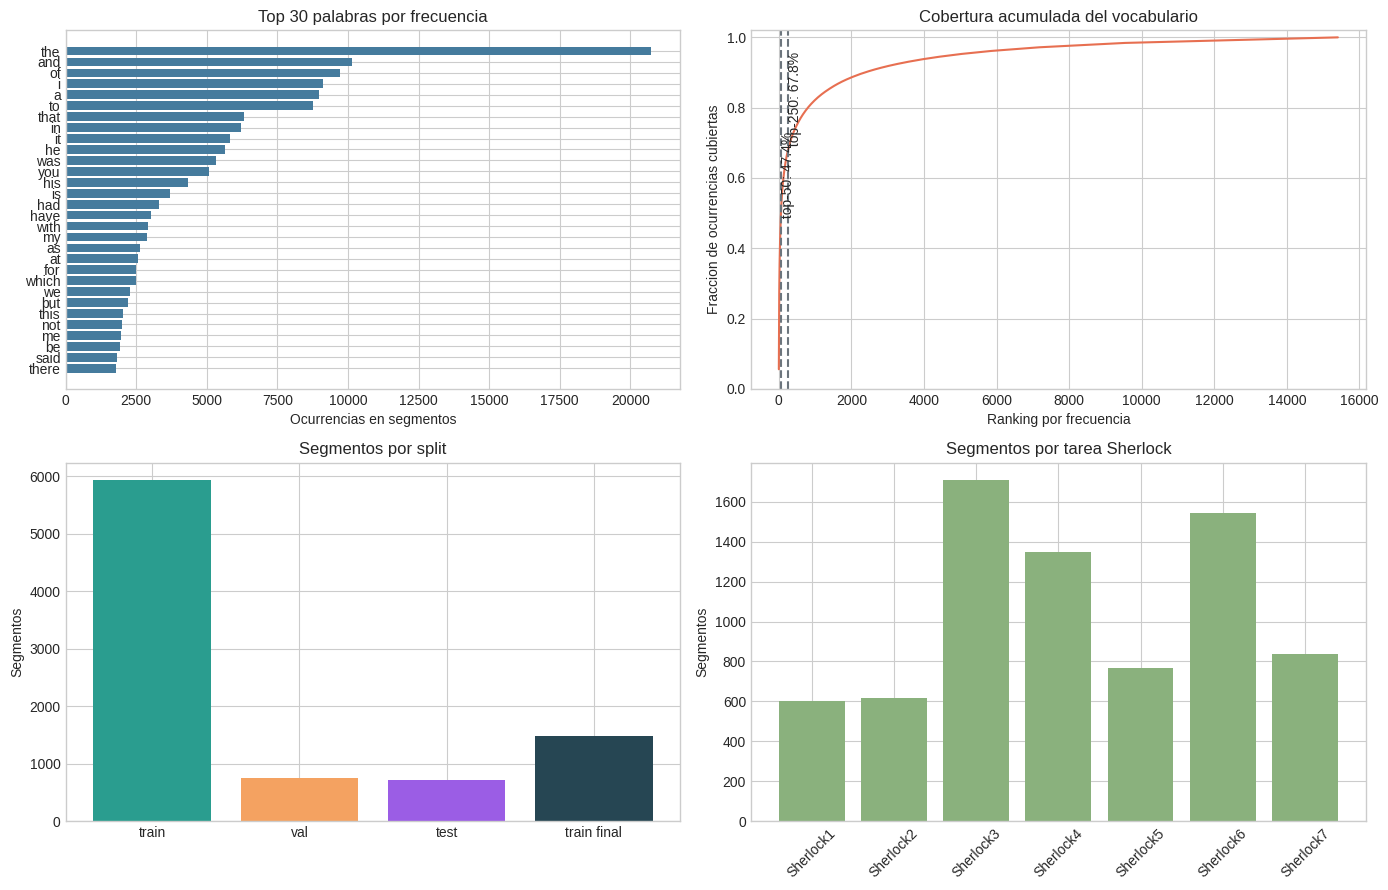

|Retrieval set|Ocurrencias cubiertas|Cobertura|
|---|---|---|
|top-50|175670|47.37%|
|top-250|251600|67.84%|

In [8]:
if not word_counter:
    print('No hay eventos suficientes para graficar frecuencias de palabras.')
else:
    top_n = 30
    top_words = word_counter.most_common(top_n)
    words = [w for w, _ in top_words]
    counts = [c for _, c in top_words]
    total_words = sum(word_counter.values())
    ordered_counts = [c for _, c in word_counter.most_common()]
    cumulative = []
    running = 0
    for count in ordered_counts:
        running += count
        cumulative.append(running / total_words)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].barh(words[::-1], counts[::-1], color='#457b9d')
    axes[0, 0].set_title(f'Top {top_n} palabras por frecuencia')
    axes[0, 0].set_xlabel('Ocurrencias en segmentos')

    axes[0, 1].plot(range(1, len(cumulative) + 1), cumulative, color='#e76f51')
    for k in eval_cfg['evaluation']['retrieval_set_sizes']:
        if k <= len(cumulative):
            axes[0, 1].axvline(k, linestyle='--', color='#6c757d')
            axes[0, 1].text(k, cumulative[k - 1], f' top-{k}: {cumulative[k - 1]:.1%}', rotation=90, va='bottom')
    axes[0, 1].set_title('Cobertura acumulada del vocabulario')
    axes[0, 1].set_xlabel('Ranking por frecuencia')
    axes[0, 1].set_ylabel('Fraccion de ocurrencias cubiertas')
    axes[0, 1].set_ylim(0, 1.02)

    split_labels = ['train', 'val', 'test']
    split_values = [split_segments[s] for s in split_labels]
    axes[1, 0].bar(split_labels, split_values, color=['#2a9d8f', '#f4a261', '#9b5de5'])
    axes[1, 0].bar(['train final'], [train_after_subsample], color='#264653')
    axes[1, 0].set_title('Segmentos por split')
    axes[1, 0].set_ylabel('Segmentos')

    task_labels, task_values = zip(*sorted(task_segments.items())) if task_segments else ([], [])
    axes[1, 1].bar(task_labels, task_values, color='#8ab17d')
    axes[1, 1].set_title('Segmentos por tarea Sherlock')
    axes[1, 1].set_ylabel('Segmentos')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    coverage_rows = []
    for k in eval_cfg['evaluation']['retrieval_set_sizes']:
        covered = sum(ordered_counts[:k]) if k <= len(ordered_counts) else total_words
        coverage_rows.append((f'top-{k}', covered, f'{covered / total_words:.2%}'))
    display(Markdown(md_table(['Retrieval set', 'Ocurrencias cubiertas', 'Cobertura'], coverage_rows)))

## MEG-XL: que se entrena realmente aqui

En el codigo, MEG-XL corresponde al `CrissCrossTransformerModule`. Conviene separar dos niveles:

1. **Preentrenamiento MEG-XL original**: BioCodec discretiza la senal MEG en codigos RVQ. El transformer recibe embeddings de esos codigos mas informacion espacial de sensores, enmascara bloques temporales y aprende a predecir los codigos BioCodec ocultos.
2. **Evaluacion de este script**: se carga ese checkpoint y se usa como extractor/fine-tune para convertir una ventana MEG alineada a una palabra en un embedding de 1024 dimensiones que debe parecerse al embedding T5 de esa palabra.

La diferencia es importante: `run_libribrain_evals.sh` no lanza el preentrenamiento enmascarado de MEG-XL desde cero. Lanza dos tareas de alineamiento palabra-MEG sobre LibriBrain: una con fine-tuning del backbone y una con backbone congelado.

|Servicio|Modo|Proyeccion por palabra|Escala|
|---|---|---|---|
|eval_libribrain|Fine-tuning MEG-XL + MLP|156672 -> 2048 -> 1024|~322,968,576 parametros en la cabeza; backbone actualizable|
|eval_libribrain_linear_probe|MEG-XL congelado + linear probe|156672 -> 1024|~160,433,152 parametros entrenables|

### Tensores principales
|Objeto|Forma|Detalle|
|---|---|---|
|MEG del batch|[B, C, T]|C=306, T=7500 muestras (150.0 s a 50.0 Hz)|
|Codigos BioCodec|[B, C, Q, T']|Q=6, T'=625, codebook=256|
|Features MEG-XL|[B, C, T', 512]|salida del criss-cross transformer antes del output head|
|Ventana por palabra|[C, ~13, 512]|3.0 s = 150 muestras -> ~13 pasos BioCodec|
|Embedding MEG predicho|[1024]|MLP o capa lineal sobre mean-pool temporal + flatten de canales|
|Embedding T5 objetivo|[1024]|T5-large layer 12, mean-pool de subtokens sin token final|

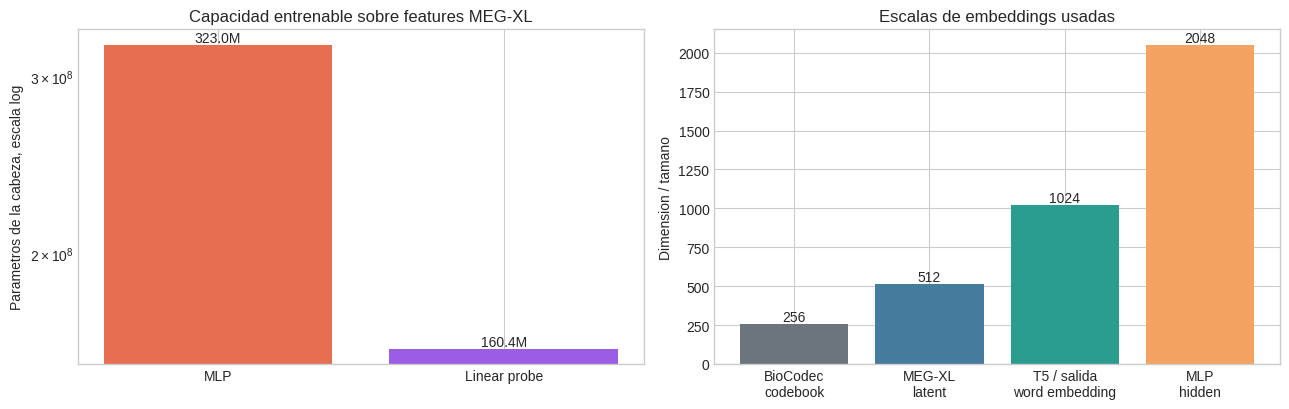

In [9]:
latent_dim = 512
num_channels = data_cfg['max_channel_dim']
mlp_input = num_channels * latent_dim
mlp_hidden = eval_cfg['model']['word_mlp']['hidden_dim']
embed_dim = eval_cfg['model']['word_mlp']['embed_dim']
linear_embed_dim = linear_cfg['model']['linear_probe']['embed_dim']
bio_downsample = 12
bio_rvq_levels = 6
bio_codebook_size = 256
segment_samples = int(data_cfg['segment_length'] * data_cfg['target_sfreq'])
word_samples = int(data_cfg['subsegment_duration'] * data_cfg['target_sfreq'])
encoded_steps = segment_samples // bio_downsample
word_encoded_steps = (word_samples + bio_downsample - 1) // bio_downsample

mlp_params = mlp_input * mlp_hidden + mlp_hidden + 2 * mlp_hidden + mlp_hidden * embed_dim + embed_dim
linear_params = mlp_input * linear_embed_dim + linear_embed_dim

model_rows = [
    ('eval_libribrain', 'Fine-tuning MEG-XL + MLP', f'{mlp_input} -> {mlp_hidden} -> {embed_dim}', f'~{mlp_params:,} parametros en la cabeza; backbone actualizable'),
    ('eval_libribrain_linear_probe', 'MEG-XL congelado + linear probe', f'{mlp_input} -> {linear_embed_dim}', f'~{linear_params:,} parametros entrenables'),
]
display(Markdown(md_table(['Servicio', 'Modo', 'Proyeccion por palabra', 'Escala'], model_rows)))

shape_rows = [
    ('MEG del batch', '[B, C, T]', f"C={num_channels}, T={segment_samples} muestras ({data_cfg['segment_length']} s a {data_cfg['target_sfreq']} Hz)"),
    ('Codigos BioCodec', '[B, C, Q, T\']', f'Q={bio_rvq_levels}, T\'={encoded_steps}, codebook={bio_codebook_size}'),
    ('Features MEG-XL', '[B, C, T\', 512]', 'salida del criss-cross transformer antes del output head'),
    ('Ventana por palabra', '[C, ~13, 512]', f"{data_cfg['subsegment_duration']} s = {word_samples} muestras -> ~{word_encoded_steps} pasos BioCodec"),
    ('Embedding MEG predicho', '[1024]', 'MLP o capa lineal sobre mean-pool temporal + flatten de canales'),
    ('Embedding T5 objetivo', '[1024]', 'T5-large layer 12, mean-pool de subtokens sin token final'),
]
display(Markdown('### Tensores principales\n' + md_table(['Objeto', 'Forma', 'Detalle'], shape_rows)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(['MLP', 'Linear probe'], [mlp_params, linear_params], color=['#e76f51', '#9b5de5'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Parametros de la cabeza, escala log')
axes[0].set_title('Capacidad entrenable sobre features MEG-XL')
for label, value in zip(['MLP', 'Linear probe'], [mlp_params, linear_params]):
    axes[0].text(label, value, f'{value/1e6:.1f}M', ha='center', va='bottom')

dims = [('BioCodec\ncodebook', bio_codebook_size), ('MEG-XL\nlatent', latent_dim), ('T5 / salida\nword embedding', embed_dim), ('MLP\nhidden', mlp_hidden)]
axes[1].bar([x for x, _ in dims], [y for _, y in dims], color=['#6c757d', '#457b9d', '#2a9d8f', '#f4a261'])
axes[1].set_ylabel('Dimension / tamano')
axes[1].set_title('Escalas de embeddings usadas')
for label, value in dims:
    axes[1].text(label, value, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Entrenamiento original de MEG-XL

El checkpoint `CRISS_CROSS_CHECKPOINT` viene de un modelo autosupervisado. Su mecanica es esta:

1. **Tokenizacion BioCodec**: cada canal MEG se procesa como una senal 1D. BioCodec usa un encoder SEANet y un cuantizador RVQ de 6 niveles con 256 codigos por nivel. La senal se reduce temporalmente por un factor 12.
2. **Embeddings de codigos**: cada codigo discreto se convierte en un vector de codebook. Los 6 niveles RVQ se concatenan y pasan por `rvq_projector` para producir un embedding continuo de 512 dimensiones por canal y timestep codificado.
3. **Embeddings espaciales**: al embedding temporal se le suman embeddings Fourier de posicion XYZ del sensor, orientacion ABC y tipo de sensor. Asi el mismo patron temporal no se interpreta igual en cualquier canal.
4. **Enmascarado temporal**: durante el preentrenamiento, se eligen subsegmentos temporales, se sustituye la parte BioCodec por un `mask_token` y se preserva la informacion espacial.
5. **Criss-cross transformer**: alterna atencion temporal dentro de cada canal y atencion espacial entre canales para cada timestep.
6. **Objetivo**: el `output_head` predice los codigos RVQ originales de las posiciones enmascaradas. Es un objetivo de reconstruccion discreta, no de palabras.

En este notebook llamo a esa representacion `features MEG-XL`: tensor `[B, C, T', 512]` justo antes del `output_head` de reconstruccion.

## Entrenamiento lanzado por `run_libribrain_evals.sh`

Dentro de las evaluaciones de LibriBrain, el forward de MEG-XL se llama con `apply_mask=False`. Por tanto no se intenta resolver el objetivo autosupervisado de codigos enmascarados. El entrenamiento supervisado por palabras ocurre asi:

1. El batch contiene segmentos MEG de 150 s: 50 ventanas consecutivas de 3 s alineadas a 50 palabras.
2. MEG-XL convierte cada segmento completo en `features [B, C, T', 512]`.
3. Para cada palabra se toma su rango temporal dentro de `T'`, se promedia en tiempo y se aplana por canales: `[C, 512] -> [C*512]`.
4. La cabeza aprende a proyectar ese vector al espacio T5 de 1024 dimensiones.
5. La perdida SigLIP compara el embedding MEG predicho contra el embedding T5 correcto y contra los otros embeddings del batch como negativos.

`eval_libribrain` actualiza MEG-XL y la MLP con learning rates distintos (`criss_cross_lr=1e-5`, `word_mlp_lr=1e-3`). `eval_libribrain_linear_probe` congela MEG-XL y solo actualiza la capa lineal (`probe_lr=1e-3`).

## Como funcionan especificamente los embeddings

Hay tres espacios de embedding distintos:

1. **BioCodec embeddings**: son embeddings internos de codigos discretos. Representan fragmentos de senal, no palabras. MEG-XL los usa como entrada.
2. **MEG-XL features**: son embeddings contextuales de 512 dimensiones por canal y tiempo. Ya mezclan informacion temporal, espacial y de sensores.
3. **Word embeddings T5**: son embeddings linguisticos de 1024 dimensiones por palabra. Son los objetivos contra los que se entrena la cabeza de evaluacion.

El punto central de la evaluacion es aprender un mapa `MEG window -> T5 word embedding`. Si el mapa funciona, el embedding predicho desde MEG deberia quedar cerca del embedding T5 de la palabra escuchada y lejos de embeddings T5 de otras palabras.

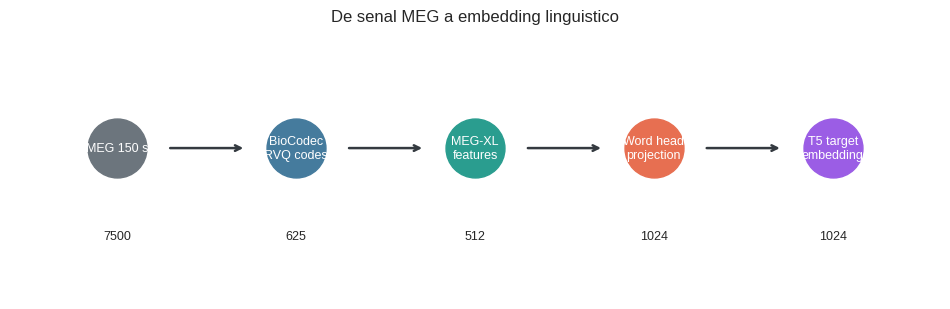

|Elemento|Operacion|Salida|
|---|---|---|
|T5 objetivo|lowercase(word) -> tokenizer T5 -> hidden_states[layer=12] -> descartar </s> -> mean pooling|[1024]|
|Cache T5|word_embeddings_{dataset}_{vocab_size}_layer{layer}_{hash}.pt|hash del vocabulario ordenado|
|MEG predicho MLP|mean_pool_t(features palabra) -> flatten canales -> Linear/LayerNorm/GELU/Dropout/Linear|[1024]|
|MEG predicho linear|mean_pool_t(features palabra) -> flatten canales -> Linear|[1024]|
|Similitud para retrieval|normalizacion L2 + producto punto contra embeddings T5 del retrieval set|top-10|

In [10]:
embedding_flow = [
    ('MEG 150 s', segment_samples),
    ('BioCodec\nRVQ codes', encoded_steps),
    ('MEG-XL\nfeatures', latent_dim),
    ('Word head\nprojection', embed_dim),
    ('T5 target\nembedding', embed_dim),
]

fig, ax = plt.subplots(figsize=(12, 3.5))
xs = range(len(embedding_flow))
colors = ['#6c757d', '#457b9d', '#2a9d8f', '#e76f51', '#9b5de5']
for x, ((label, value), color) in enumerate(zip(embedding_flow, colors)):
    ax.scatter(x, 0, s=1800, color=color)
    ax.text(x, 0, label, ha='center', va='center', color='white', fontsize=9)
    ax.text(x, -0.38, str(value), ha='center', va='top', fontsize=9)
    if x < len(embedding_flow) - 1:
        ax.annotate('', xy=(x + 0.72, 0), xytext=(x + 0.28, 0), arrowprops=dict(arrowstyle='->', lw=1.8, color='#343a40'))
ax.set_xlim(-0.6, len(embedding_flow) - 0.4)
ax.set_ylim(-0.7, 0.55)
ax.axis('off')
ax.set_title('De senal MEG a embedding linguistico')
plt.show()

embedding_detail_rows = [
    ('T5 objetivo', 'lowercase(word) -> tokenizer T5 -> hidden_states[layer=12] -> descartar </s> -> mean pooling', '[1024]'),
    ('Cache T5', 'word_embeddings_{dataset}_{vocab_size}_layer{layer}_{hash}.pt', 'hash del vocabulario ordenado'),
    ('MEG predicho MLP', 'mean_pool_t(features palabra) -> flatten canales -> Linear/LayerNorm/GELU/Dropout/Linear', '[1024]'),
    ('MEG predicho linear', 'mean_pool_t(features palabra) -> flatten canales -> Linear', '[1024]'),
    ('Similitud para retrieval', 'normalizacion L2 + producto punto contra embeddings T5 del retrieval set', f'top-{eval_cfg["evaluation"]["k"]}'),
]
display(Markdown(md_table(['Elemento', 'Operacion', 'Salida'], embedding_detail_rows)))

## Perdida y metricas de embeddings

La perdida `SigLipLoss` no clasifica con una softmax fija sobre todo el vocabulario. Construye una matriz de similitudes entre embeddings MEG predichos y embeddings T5 candidatos del batch:

- normaliza ambos lados porque `norm_kind="xy"`;
- multiplica por una temperatura aprendible;
- suma un sesgo aprendible;
- usa binary cross entropy con positivos en la diagonal y, si dos candidatos T5 son casi identicos, los trata como duplicados positivos.

Despues, la evaluacion hace retrieval sobre vocabularios ordenados por frecuencia. Para `top-10@250`, por ejemplo, solo considera muestras cuya palabra verdadera esta entre las 250 mas frecuentes, calcula la similitud del embedding MEG contra esos 250 embeddings T5 y acierta si la palabra correcta aparece entre los 10 vecinos mas cercanos.

## Que hace cada evaluacion dentro del contenedor

Ambas evaluaciones siguen este pipeline operativo:

1. Inicializan logging, WandB en el modo heredado de `WANDB_MODE`, seed y directorio de salida.
2. Cargan el tokenizer BioCodec y el checkpoint MEG-XL/CrissCross indicado por `CRISS_CROSS_CHECKPOINT`.
3. Construyen `LibriBrainWordAlignedDataset`, que descubre HDF5 + eventos, re-preprocesa si la frecuencia/corte no coincide y cachea en `data/cache`.
4. Agrupan palabras en segmentos de `words_per_segment`; cada palabra aporta una ventana de `subsegment_duration` segundos empezando `window_onset_offset` antes del onset.
5. Asignan cada frase a `train/val/test` con hash SHA256 y ratios `split_ratios`; despues submuestrean train con `train_pct`.
6. Construyen vocabulario con todas las palabras de los segmentos, ordenado por frecuencia.
7. Generan o cargan embeddings T5-large layer 12 en `embeddings_cache`.
8. Entrenan el mapa `MEG window -> T5 embedding` con perdida SigLIP y evaluan retrieval `top-10` contra los conjuntos top-50 y top-250.
9. Guardan checkpoints en el `logging.save_dir` de cada config y reportan metricas finales.

## Primeros resultados

Estos son los primeros resultados reportados para `eval_libribrain`, es decir, la variante con fine-tuning de MEG-XL y cabeza MLP. Proceden de `logs/word_classification_libribrain/final_results.txt`.

Lectura rapida: el modelo recupera la palabra correcta dentro del top-10 en el 66.94% de las muestras evaluables cuando el conjunto de candidatos son las 50 palabras mas frecuentes. Al ampliar el retrieval set a 250 palabras, la tarea se vuelve mas dificil y baja a 45.00%. La accuracy balanceada cae mas fuerte en top-250, lo que sugiere que las clases frecuentes pesan mucho en la accuracy agregada y que todavia hay margen en palabras menos representadas.


In [11]:
reported_results = {
    'loss': 4.1463,
    'top10_accuracy_retrieval50': 0.6694,
    'n_samples_retrieval50': 18290,
    'n_skipped_retrieval50': 20060,
    'balanced_top10_accuracy_retrieval50': 0.5902,
    'top10_accuracy_retrieval250': 0.4500,
    'n_samples_retrieval250': 25985,
    'n_skipped_retrieval250': 12365,
    'balanced_top10_accuracy_retrieval250': 0.2192,
    'mean_cosine_similarity': 0.6797,
    'std_cosine_similarity': 0.0847,
    'mean_pred_norm': 127.2071,
    'std_pred_norm': 51.7157,
    'mean_target_norm': 2480.5745,
}

results_file = ROOT / 'logs/word_classification_libribrain/final_results.txt'
if results_file.exists():
    parsed = {}
    for line in results_file.read_text().splitlines():
        if ':' not in line:
            continue
        key, value = line.split(':', 1)
        key = key.strip()
        value = value.strip()
        try:
            parsed[key] = float(value)
        except ValueError:
            pass
    if parsed:
        reported_results.update(parsed)

retrieval_rows = []
for size in [50, 250]:
    n_eval = int(reported_results[f'n_samples_retrieval{size}'])
    n_skip = int(reported_results[f'n_skipped_retrieval{size}'])
    total = n_eval + n_skip
    retrieval_rows.append((
        f'top-10@{size}',
        f"{reported_results[f'top10_accuracy_retrieval{size}']:.2%}",
        f"{reported_results[f'balanced_top10_accuracy_retrieval{size}']:.2%}",
        f'{n_eval:,}',
        f'{n_skip:,}',
        f'{n_eval / total:.2%}',
    ))

embedding_rows = [
    ('loss', f"{reported_results['loss']:.4f}", 'SigLIP final en test'),
    ('mean cosine similarity', f"{reported_results['mean_cosine_similarity']:.4f}", 'similitud media MEG embedding vs T5 objetivo'),
    ('std cosine similarity', f"{reported_results['std_cosine_similarity']:.4f}", 'dispersion de la similitud coseno'),
    ('mean pred norm', f"{reported_results['mean_pred_norm']:.2f}", 'norma media del embedding predicho desde MEG'),
    ('std pred norm', f"{reported_results['std_pred_norm']:.2f}", 'dispersion de normas predichas'),
    ('mean target norm', f"{reported_results['mean_target_norm']:.2f}", 'norma media de embeddings T5 objetivo'),
]

display(Markdown('### Retrieval test metrics\n' + md_table(
    ['Metrica', 'Accuracy', 'Balanced accuracy', 'Muestras evaluadas', 'Muestras omitidas', 'Cobertura'],
    retrieval_rows,
)))
display(Markdown('### Calidad de embeddings\n' + md_table(['Metrica', 'Valor', 'Interpretacion'], embedding_rows)))


### Retrieval test metrics
|Metrica|Accuracy|Balanced accuracy|Muestras evaluadas|Muestras omitidas|Cobertura|
|---|---|---|---|---|---|
|top-10@50|66.94%|59.02%|18,290|20,060|47.69%|
|top-10@250|45.00%|21.92%|25,985|12,365|67.76%|

### Calidad de embeddings
|Metrica|Valor|Interpretacion|
|---|---|---|
|loss|4.1463|SigLIP final en test|
|mean cosine similarity|0.6797|similitud media MEG embedding vs T5 objetivo|
|std cosine similarity|0.0847|dispersion de la similitud coseno|
|mean pred norm|127.21|norma media del embedding predicho desde MEG|
|std pred norm|51.72|dispersion de normas predichas|
|mean target norm|2480.57|norma media de embeddings T5 objetivo|

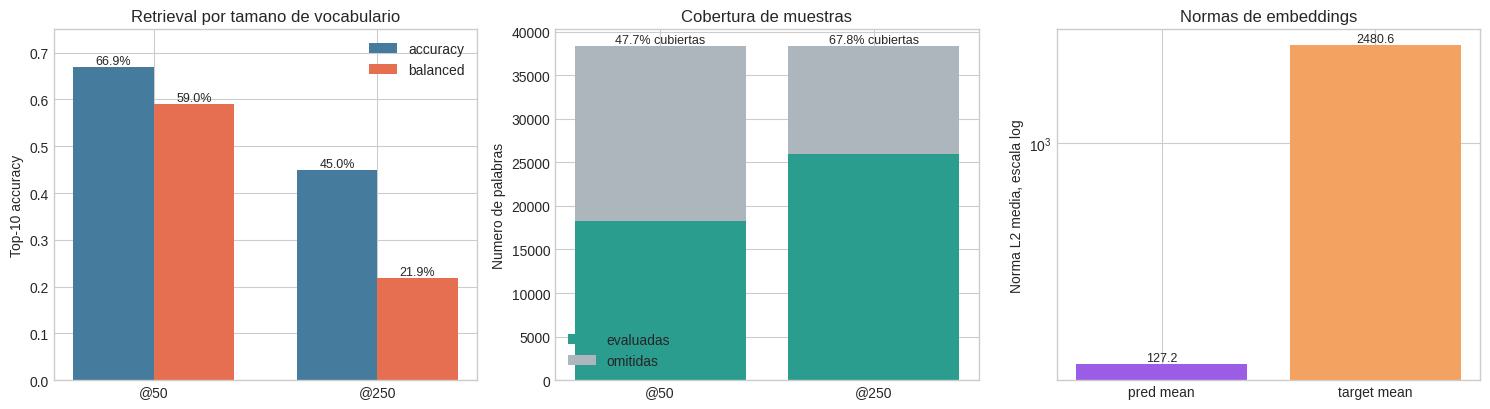

Cosine similarity media: 0.6797 +/- 0.0847


In [12]:
retrieval_sizes = [50, 250]
acc = [reported_results[f'top10_accuracy_retrieval{s}'] for s in retrieval_sizes]
balanced = [reported_results[f'balanced_top10_accuracy_retrieval{s}'] for s in retrieval_sizes]
samples = [reported_results[f'n_samples_retrieval{s}'] for s in retrieval_sizes]
skipped = [reported_results[f'n_skipped_retrieval{s}'] for s in retrieval_sizes]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
x = range(len(retrieval_sizes))
width = 0.36

axes[0].bar([i - width/2 for i in x], acc, width=width, label='accuracy', color='#457b9d')
axes[0].bar([i + width/2 for i in x], balanced, width=width, label='balanced', color='#e76f51')
axes[0].set_xticks(list(x), [f'@{s}' for s in retrieval_sizes])
axes[0].set_ylim(0, 0.75)
axes[0].set_ylabel('Top-10 accuracy')
axes[0].set_title('Retrieval por tamano de vocabulario')
axes[0].legend()
for i, value in enumerate(acc):
    axes[0].text(i - width/2, value, f'{value:.1%}', ha='center', va='bottom', fontsize=9)
for i, value in enumerate(balanced):
    axes[0].text(i + width/2, value, f'{value:.1%}', ha='center', va='bottom', fontsize=9)

axes[1].bar([f'@{s}' for s in retrieval_sizes], samples, label='evaluadas', color='#2a9d8f')
axes[1].bar([f'@{s}' for s in retrieval_sizes], skipped, bottom=samples, label='omitidas', color='#adb5bd')
axes[1].set_title('Cobertura de muestras')
axes[1].set_ylabel('Numero de palabras')
axes[1].legend()
for i, (n_eval, n_skip) in enumerate(zip(samples, skipped)):
    total = n_eval + n_skip
    axes[1].text(i, total, f'{n_eval/total:.1%} cubiertas', ha='center', va='bottom', fontsize=9)

norm_labels = ['pred mean', 'target mean']
norm_values = [reported_results['mean_pred_norm'], reported_results['mean_target_norm']]
axes[2].bar(norm_labels, norm_values, color=['#9b5de5', '#f4a261'])
axes[2].set_yscale('log')
axes[2].set_title('Normas de embeddings')
axes[2].set_ylabel('Norma L2 media, escala log')
for label, value in zip(norm_labels, norm_values):
    axes[2].text(label, value, f'{value:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Cosine similarity media: {reported_results['mean_cosine_similarity']:.4f} +/- {reported_results['std_cosine_similarity']:.4f}")


### Interpretacion

- `top-10@50 = 66.94%`: con un vocabulario muy frecuente y compacto, el embedding MEG predicho suele caer cerca del embedding T5 correcto.
- `top-10@250 = 45.00%`: al introducir mas candidatos, sube la confusion semantica/acustica y baja la probabilidad de que la palabra correcta quede en los 10 vecinos mas cercanos.
- `balanced@250 = 21.92%`: la diferencia entre accuracy agregada y balanceada indica que el rendimiento no es uniforme por clase; las palabras raras o menos estables pesan mas en esta metrica.
- La similitud coseno media de `0.6797` indica alineamiento claro entre embeddings MEG y T5, aunque las normas de T5 son mucho mayores que las normas predichas; como las metricas de retrieval normalizan por coseno, la direccion del embedding importa mas que la escala.


## Salidas esperadas

- Logs de contenedor: `docker compose logs -f eval_libribrain` y `docker compose logs -f eval_libribrain_linear_probe`.
- Monitor local si no se pasa `--no-monitor`: `http://localhost:$MONITOR_PORT`, por defecto `http://localhost:8080`.
- Runs Hydra: `logs/hydra/eval_libribrain/<timestamp>` y `logs/hydra/eval_libribrain_linear_probe/<timestamp>`.
- Checkpoints/metricas de evaluacion: `logs/word_classification_libribrain` y `logs/word_classification_linear_probe_libribrain`.
- Caches: `data/cache`, `embeddings_cache`, `hf_cache` y `wandb`.

Para ejecutar solo una parte, usa los flags descritos arriba. Para una ejecucion completa con logs en vivo:

```bash
bash run_libribrain_evals.sh --logs
```